## Manufacturing Defect Classification Model

## Project Overview

**AutomaParts S.p.A.** is a tier-1 supplier in the automotive industry, specializing in precision mechanical components for steering and suspension systems.

The objective of this project is to develop a supervised machine learning model in Python to classify conforming and defective parts directly within the production line.

The model is designed to support operational decisions aimed at:
- reducing scrap and rework costs  
- improving product quality  
- optimizing inspection processes  

The solution is intended to be applied to real production data, including dimensional measurements, process parameters, sensor signals, and contextual information related to production lines and operators.

The project includes:
- exploratory data analysis  
- missing data handling  
- feature engineering  
- model training and evaluation (Decision Tree, Random Forest, Logistic Regression)  
- assessment of model generalization  

---

## Use Case

In a production line assembling suspension arms, multiple characteristics are measured for each part (e.g., diameters, flatness, torque, process temperature).

Some parts fall outside tolerance limits, causing machine downtime or customer returns.

The model predicts the probability of a part being defective at the end of the in-line inspection process, enabling:

- automatic rejection or routing to final inspection  
- escalation to 100% inspection in uncertain cases  
- identification of root causes of defects for process improvement  

---

## Business Impact

- reduction of scrap and rework costs  
- increase in First Pass Yield  
- reduction of non-conformity risks toward OEM customers  
- improved production line efficiency  

---

## Added Value

- traceability of defect causes aggregated by machine, batch, or operator  
- support for maintenance decisions  
- potential integration with MES systems for automated actions  

---

## Dataset

File: `parts_production_data.csv`  
(available in the repository under `/data/`)

### Columns

1. `part_id`: unique part identifier  
2. `production_timestamp`: production timestamp (used for time-based analysis)  
3. `line_id`: production line identifier  
4. `station_id`: measurement station identifier  
5. `operator_id`: operator identifier (anonymized if needed)  
6. `measure_diam_mm`: dimensional measurement (mm)  
7. `measure_length_mm`: longitudinal measurement (mm)  
8. `flatness_mm`: surface flatness (mm)  
9. `torque_Nm`: recorded torque value  
10. `surface_roughness_Ra`: surface roughness  
11. `temp_process_C`: process temperature (°C)  
12. `vibration_level`: measured vibration level  
13. `cycle_time_s`: machine cycle time  
14. `material_batch`: raw material batch  
15. `visual_inspection_score`: visual inspection score (if available)  
16. `defect_label`: binary label (0 = conforming, 1 = defective)  

---

## Project Objectives

The project includes the following key activities:

### 1. Exploratory Data Analysis
- analysis of variable distributions and relationships  
- identification of class imbalance (defective vs conforming)  
- creation of visual insights for stakeholders  

---

### 2. Data Cleaning & Missing Values
- identification of missing data  
- evaluation of impact on analysis  
- handling of incomplete records and outliers  

---

### 3. Feature Engineering
- encoding of categorical variables  
- normalization/scaling of numerical features  
- creation of derived features where relevant  

---

### 4. Data Splitting & Generalization
- definition of training and test datasets  
- evaluation of model performance on unseen data  
- validation of robustness in production scenarios  

---

### 5. Model Training & Comparison
- training of baseline models:
  - Decision Tree  
  - Random Forest  
  - Logistic Regression  

- comparison of performance and suitability for industrial use  

---

### 6. Model Evaluation
- evaluation metrics:
  - accuracy  
  - precision  
  - recall  
  - F1 score  
  - ROC-AUC  

- analysis of:
  - false negatives (defective parts classified as conforming)  
  - false positives  

---

### 7. Interpretability & Operational Use
- identification of most relevant features  
- evaluation of model applicability in production  
- assessment of prediction reliability  

---

### 8. Conclusions & Recommendations
- summary of results and preferred model  
- operational recommendations (e.g. thresholds, monitoring)  
- suggestions for further improvements and data collection  

---

## Quality Requirements & Constraints

- clear documentation of assumptions and modeling choices  
- compliance with data privacy (e.g. anonymization of operator identifiers)  
- consideration of model robustness against process variations and data bias  

---

## Evaluation Criteria

- completeness of exploratory analysis  
- correct handling of missing data  
- consistency in feature preparation and data splitting  
- quality of model comparison and interpretation  
- clarity of conclusions and operational recommendations  

---

## Final Objective

The goal of this project is to provide AutomaParts S.p.A. with a decision-support tool to improve production quality and reduce costs related to defective parts.

Beyond predictive accuracy, the real value lies in:
- evaluating the operational impact of errors (especially false negatives)  
- identifying root causes  
- enabling integration with real production processes

# Execution

## 0 - Set-Up

In [264]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, log_loss, accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from datetime import datetime


In [ ]:
df = pd.read_csv(r"https://raw.githubusercontent.com/Drenthe24/manufacturing-defect-classification/refs/heads/main/data/parts_production_data.csv")

## 1 - Exploratory Dataset Analysis

### Dataset Analysis

**Dataset Overview**

The dataset contains production data related to mechanical components in the automotive industry.

**Dataset Size**
- 3,000 observations  
- 16 variables  

**Identifiers**
- `part_id`: unique part identifier  
- `line_id`: production line identifier  
- `station_id`: measurement station identifier  
- `operator_id`: operator identifier (anonymized)  
- `material_batch`: raw material batch  

**Process & Measurement Variables**
- `measure_diam_mm`: dimensional measurement (mm)  
- `measure_length_mm`: longitudinal measurement (mm)  
- `flatness_mm`: surface flatness (mm)  
- `torque_Nm`: recorded torque value  
- `surface_roughness_Ra`: surface roughness  
- `temp_process_C`: process temperature (°C)  
- `vibration_level`: vibration level  
- `cycle_time_s`: machine cycle time  
- `visual_inspection_score`: visual inspection score  

**Time Variable**
- `production_timestamp`: production date and time  

**Target Variable**
- `defect_label`: binary label  
  - 0 → conforming part  
  - 1 → defective part  

**Notes**

The dataset includes a mix of numerical and categorical variables, as well as time-based information, making it suitable for both statistical analysis and machine learning modeling.

The target variable is imbalanced, reflecting real-world production scenarios where defective parts are typically less frequent.

In [266]:
df.shape

(3000, 16)

In [267]:
df.head(10)

,part_id,production_timestamp,line_id,station_id,operator_id,measure_diam_mm,measure_length_mm,flatness_mm,torque_Nm,surface_roughness_Ra,temp_process_C,vibration_level,cycle_time_s,material_batch,visual_inspection_score,defect_label
0,1,2024-06-13 17:42:45,2,1,5,15.582,34.100,34.813,318.147,33.620,72.543,0.093695,146.532,MB-2024W24-L02-575,0.602019,1
1,2,2024-07-26 10:36:48,9,14,4,42.377,30.260,36.116,379.256,23.610,82.438,0.957213,167.319,MB-2024W30-L09-100,0.092746,0
2,3,2025-12-08 17:35:40,6,20,5,25.141,52.082,36.588,347.408,44.468,116.188,0.704572,109.165,MB-2025W50-L06-297,0.227898,0
3,4,2024-12-09 12:56:36,4,4,7,35.427,44.593,27.404,183.803,20.679,144.932,0.648035,221.826,MB-2024W50-L04-747,0.171139,0
4,5,2025-09-08 15:54:15,8,13,5,22.618,40.710,24.220,477.164,45.055,95.174,0.655439,179.126,MB-2025W37-L08-470,0.914548,1
5,6,2025-07-25 14:06:34,3,8,9,33.383,65.913,27.988,187.728,49.902,110.762,0.090909,109.423,MB-2025W30-L03-643,0.109649,1
6,7,2025-02-06 08:10:08,7,20,2,20.057,52.129,38.849,372.113,14.582,140.783,0.750878,253.720,MB-2025W06-L07-301,0.340175,0
7,8,2025-01-20 16:38:06,8,1,5,46.505,64.821,25.969,355.580,34.359,82.227,0.762511,207.876,MB-2025W04-L08-544,0.778626,0
8,9,2025-09-29 08:07:54,10,11,8,42.271,39.578,24.817,326.943,13.150,128.553,0.816023,295.597,MB-2025W40-L10-129,0.532706,1
9,10,2025-04-07 12:29:34,8,18,3,26.926,38.472,30.786,391.972,18.046,94.937,0.995149,229.976,MB-2025W15-L08-530,0.438100,0


In [268]:
df.describe()

,part_id,line_id,station_id,operator_id,measure_diam_mm,measure_length_mm,flatness_mm,torque_Nm,surface_roughness_Ra,temp_process_C,vibration_level,cycle_time_s,visual_inspection_score,defect_label
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,5.548000,10.632333,5.497000,30.260599,49.707794,29.82437,302.045475,29.888010,110.732378,0.496433,200.483076,0.498166,0.224333
std,866.169729,2.824834,5.808362,2.868693,11.406951,11.536161,5.79796,115.859112,11.638858,23.244585,0.286117,57.751629,0.286271,0.417212
min,1.000000,1.000000,1.000000,1.000000,10.014000,30.005000,20.00300,100.085000,10.000000,70.006000,0.000092,100.094000,0.000051,0.000000
25%,750.750000,3.000000,5.750000,3.000000,20.642750,39.667250,24.74375,201.608500,19.955250,90.624750,0.253753,149.543750,0.249152,0.000000
50%,1500.500000,6.000000,11.000000,6.000000,30.277000,49.450500,29.79500,303.522000,29.670000,111.266000,0.495252,200.839500,0.510032,0.000000
75%,2250.250000,8.000000,16.000000,8.000000,39.927750,59.595000,34.84550,400.808000,40.269250,131.194250,0.744657,250.876750,0.743558,0.000000
max,3000.000000,10.000000,20.000000,10.000000,49.997000,69.986000,39.99400,499.619000,49.959000,149.968000,0.999678,299.995000,0.999857,1.000000


### Analysis of variables, distributions and correlations

#### Data Analysis & Key Insights

#### Data Quality

The dataset does not contain missing values, ensuring consistency and reliability for both analysis and modeling.

---

#### Target Variable

The target variable is binary:

- `defect_label`
  - 0 → conforming part (77.6%)
  - 1 → defective part (22.4%)

This indicates a **moderate class imbalance**, reflecting realistic production conditions where defective parts are less frequent but still significant.

---

#### Feature Cardinality

- `line_id`: 10 production lines  
- `station_id`: 20 measurement stations  
- `operator_id`: 10 operators  
- `material_batch`: 2997 unique values out of 3000 observations → low generalization potential  
- `part_id`: unique identifier → not useful as a feature  
- `production_timestamp`: time-based variable  

---

#### Feature Analysis by Target Class

Boxplot analysis was used to compare the distribution of process variables between conforming and defective parts.

##### Dimensional Variables
- `measure_diam_mm`
- `measure_length_mm`
- `flatness_mm`

The distributions are highly overlapping, with nearly identical medians.

**Insight:** dimensional deviations alone are not sufficient to explain defects.

---

##### Process Parameters
- `torque_Nm`
- `surface_roughness_Ra`
- `temp_process_C`

These variables also show similar distributions across classes.

**Insight:** defects are likely driven by **combinations of process conditions**, rather than single variables.

---

##### Notable Differences

Some variables show weak but potentially relevant signals:

- `vibration_level` → slightly higher for defective parts  
- `cycle_time_s` → slight variation between classes  
- `visual_inspection_score` → may contain useful discriminative information  

---

#### Key Insight

There is no clear separation between classes based on individual variables.

**Implication:**  
Defect classification requires models capable of capturing **multivariate relationships**.

---

#### Correlation Analysis

The correlation matrix shows very low linear correlation between variables.

- most coefficients are close to zero  
- variables are largely independent  

**Positive aspect:**
- low multicollinearity  
- features provide complementary information  

**Modeling implication:**
- defects are likely driven by **non-linear interactions** between variables  

---

#### Defect Rate Analysis

Defect rates were analyzed across production lines, stations, and operators.

##### Production Lines
- defect rate ranges between ~19% and ~28%  
- some lines show consistently higher defect rates  

suggests differences in operating conditions or machine configurations  

---

##### Stations
- higher variability across stations  
- some stations show significantly higher defect rates  

indicates potential **critical steps in the production process**  

---

##### Operators
- relatively uniform defect rates  

suggests defects are **process-driven rather than operator-dependent**

---

#### Business Insight

This analysis highlights that:

- defects are not explained by single variables  
- process conditions play a key role  
- specific lines and stations may require optimization  

The model can therefore be used not only for prediction, but also for:
- identifying critical process areas  
- supporting process improvement initiatives  
- reducing defect rates at the source

In [ ]:
df.isna().sum() 

part_id                    0
production_timestamp       0
line_id                    0
station_id                 0
operator_id                0
measure_diam_mm            0
measure_length_mm          0
flatness_mm                0
torque_Nm                  0
surface_roughness_Ra       0
temp_process_C             0
vibration_level            0
cycle_time_s               0
material_batch             0
visual_inspection_score    0
defect_label               0
dtype: int64

In [270]:
missing_counts = df.isna().sum()
missing_percentage = (df.isna().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percentage
})

missing_table

,Missing Count,Missing %
part_id,0,0.0
production_timestamp,0,0.0
line_id,0,0.0
station_id,0,0.0
operator_id,0,0.0
measure_diam_mm,0,0.0
measure_length_mm,0,0.0
flatness_mm,0,0.0
torque_Nm,0,0.0
surface_roughness_Ra,0,0.0


In [271]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   part_id                  3000 non-null   int64  
 1   production_timestamp     3000 non-null   str    
 2   line_id                  3000 non-null   int64  
 3   station_id               3000 non-null   int64  
 4   operator_id              3000 non-null   int64  
 5   measure_diam_mm          3000 non-null   float64
 6   measure_length_mm        3000 non-null   float64
 7   flatness_mm              3000 non-null   float64
 8   torque_Nm                3000 non-null   float64
 9   surface_roughness_Ra     3000 non-null   float64
 10  temp_process_C           3000 non-null   float64
 11  vibration_level          3000 non-null   float64
 12  cycle_time_s             3000 non-null   float64
 13  material_batch           3000 non-null   str    
 14  visual_inspection_score  3000 non-n

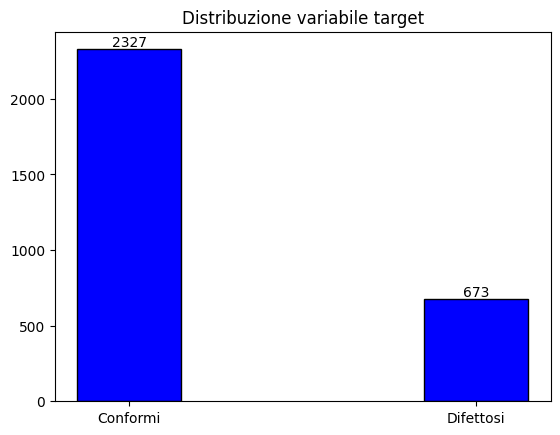

In [272]:
plt.bar_label(plt.bar(["Conformi", "Difettosi"], df["defect_label"].value_counts(), color="blue", width=0.3, edgecolor="black"), df["defect_label"].value_counts())
plt.title("Distribuzione variabile target")
plt.show()

In [273]:
# Analisi valori campi categorici
categ_columns = ["line_id", "station_id", "operator_id", "material_batch"]
for col in categ_columns:
    print(df[col].value_counts().sort_index(ascending=True))
    print("\n")

line_id
1     284
2     274
3     313
4     291
5     303
6     319
7     307
8     319
9     321
10    269
Name: count, dtype: int64


station_id
1     151
2     143
3     132
4     160
5     164
6     135
7     152
8     165
9     129
10    145
11    131
12    144
13    153
14    158
15    155
16    172
17    125
18    156
19    181
20    149
Name: count, dtype: int64


operator_id
1     313
2     287
3     300
4     293
5     298
6     295
7     312
8     316
9     300
10    286
Name: count, dtype: int64


material_batch
MB-2023W52-L01-005    1
MB-2023W52-L01-019    1
MB-2023W52-L01-218    1
MB-2023W52-L01-409    1
MB-2023W52-L01-695    1
                     ..
MB-2025W51-L08-595    1
MB-2025W51-L08-804    1
MB-2025W51-L08-862    1
MB-2025W51-L09-262    1
MB-2025W51-L10-010    1
Name: count, Length: 2997, dtype: int64




In [274]:
# Analisi parametri di misura/processo
par_processing_columns = df.drop(["defect_label", "part_id", "production_timestamp"] + categ_columns, axis=1).columns
for col in par_processing_columns:
    print("Campo: ", col)
    print("\n")
    print(df[col].describe())
    print("\n")

Campo:  measure_diam_mm


count    3000.000000
mean       30.260599
std        11.406951
min        10.014000
25%        20.642750
50%        30.277000
75%        39.927750
max        49.997000
Name: measure_diam_mm, dtype: float64


Campo:  measure_length_mm


count    3000.000000
mean       49.707794
std        11.536161
min        30.005000
25%        39.667250
50%        49.450500
75%        59.595000
max        69.986000
Name: measure_length_mm, dtype: float64


Campo:  flatness_mm


count    3000.00000
mean       29.82437
std         5.79796
min        20.00300
25%        24.74375
50%        29.79500
75%        34.84550
max        39.99400
Name: flatness_mm, dtype: float64


Campo:  torque_Nm


count    3000.000000
mean      302.045475
std       115.859112
min       100.085000
25%       201.608500
50%       303.522000
75%       400.808000
max       499.619000
Name: torque_Nm, dtype: float64


Campo:  surface_roughness_Ra


count    3000.000000
mean       29.888010
std        11.6

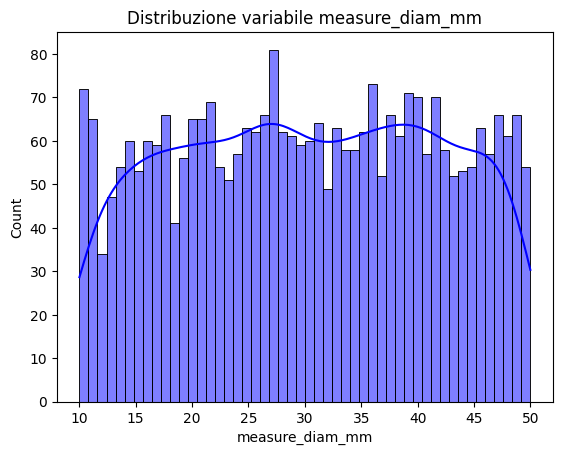

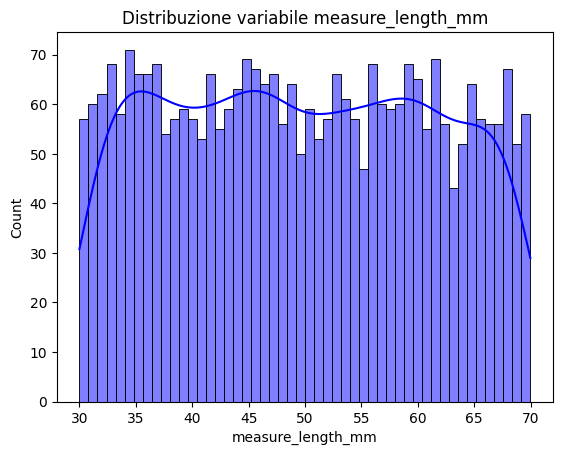

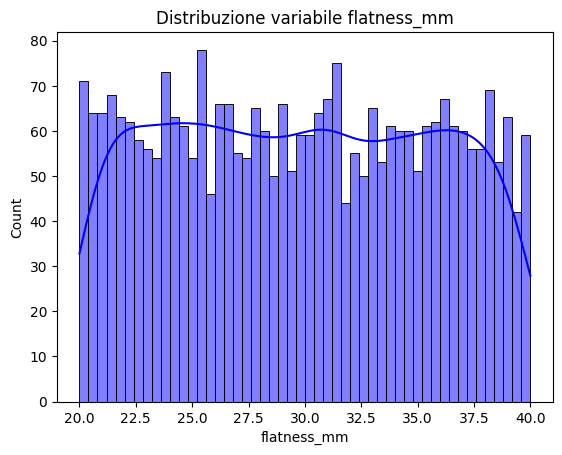

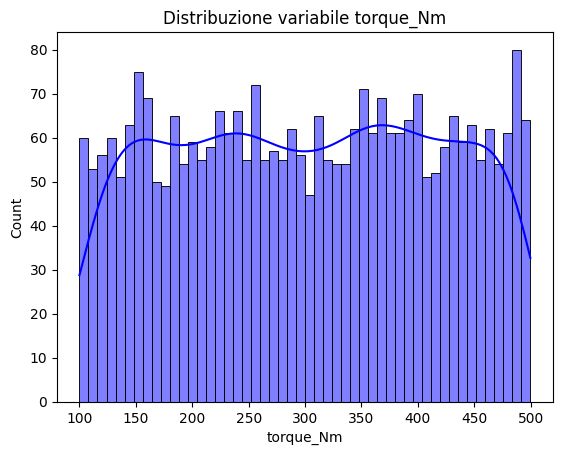

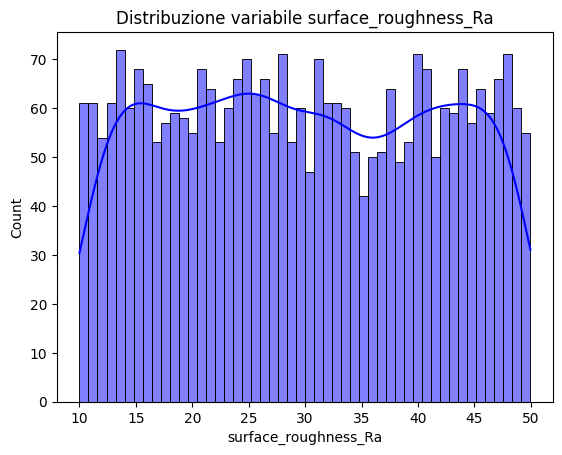

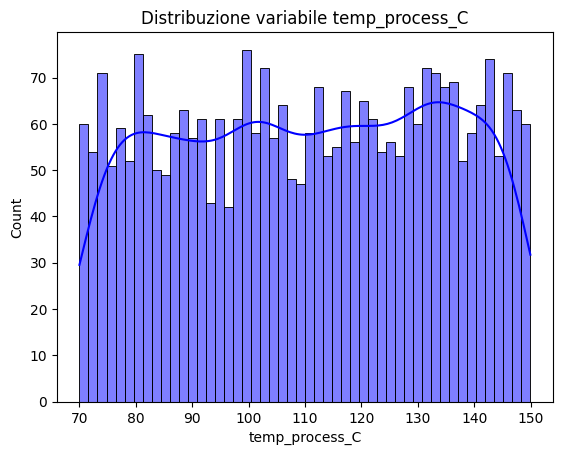

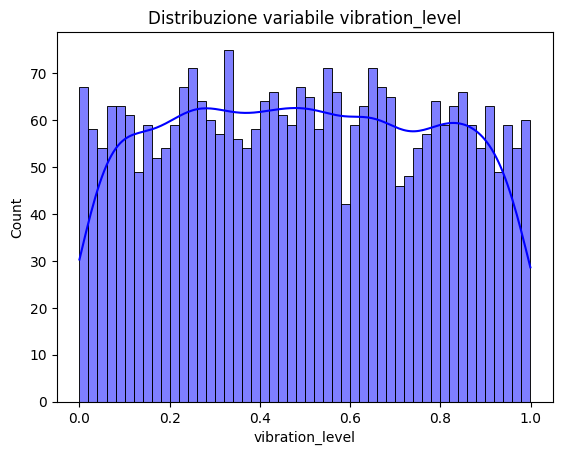

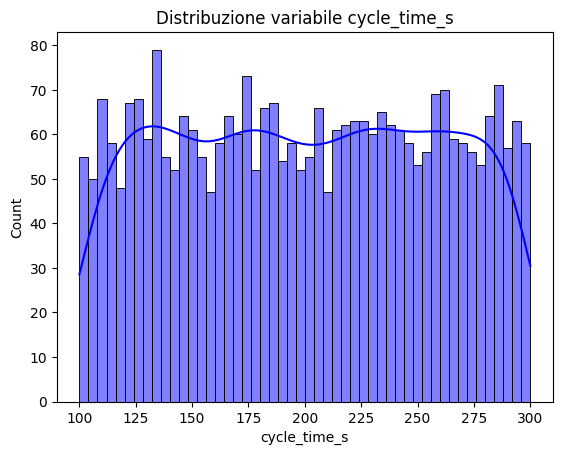

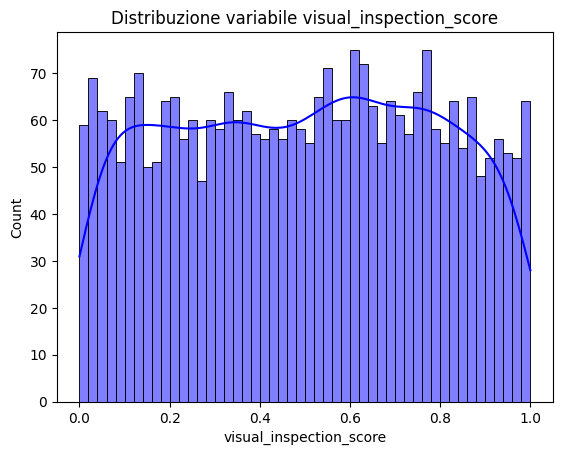

In [275]:
for col in par_processing_columns:
    sns.histplot(df[col], kde=True, bins=50, color="blue", edgecolor="black") 
    plt.title("Distribuzione variabile " + col)
    plt.show()
    

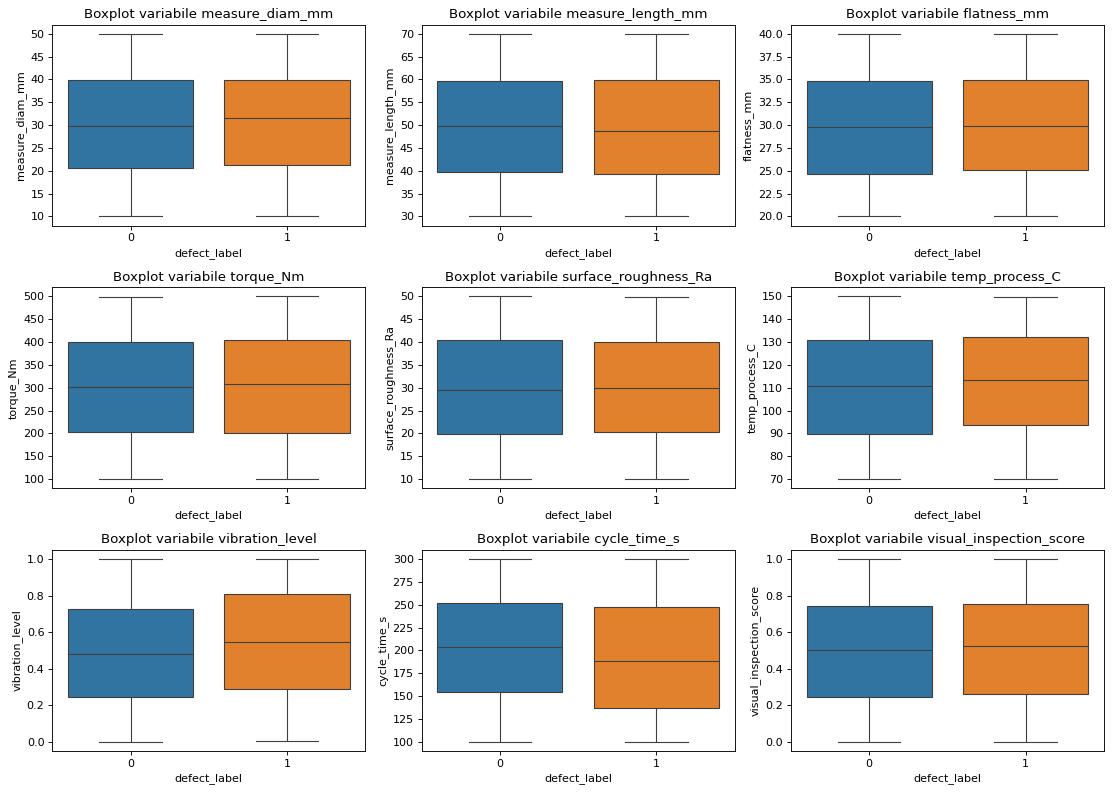

In [276]:
# Creiamo dei boxplot per ogni parametro di processo
plt.figure(figsize=(14, 10), dpi=80)
for i, col in enumerate(par_processing_columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=df, x="defect_label", y=col, hue="defect_label", legend=False)
    plt.title("Boxplot variabile " + col)
plt.tight_layout()
plt.show()

In [277]:
df[par_processing_columns].corr()

,measure_diam_mm,measure_length_mm,flatness_mm,torque_Nm,surface_roughness_Ra,temp_process_C,vibration_level,cycle_time_s,visual_inspection_score
measure_diam_mm,1.000000,-0.000618,-0.037376,-0.005780,0.021481,-0.014264,0.004691,0.000970,0.030009
measure_length_mm,-0.000618,1.000000,-0.005389,0.014149,0.007367,-0.009140,-0.006659,-0.012841,0.009151
flatness_mm,-0.037376,-0.005389,1.000000,-0.000810,-0.024439,0.015549,0.012949,-0.000639,0.046536
torque_Nm,-0.005780,0.014149,-0.000810,1.000000,0.021322,0.003033,0.006194,0.010329,0.019348
surface_roughness_Ra,0.021481,0.007367,-0.024439,0.021322,1.000000,-0.024643,-0.038653,-0.037207,-0.020831
temp_process_C,-0.014264,-0.009140,0.015549,0.003033,-0.024643,1.000000,-0.009256,-0.007231,0.010864
vibration_level,0.004691,-0.006659,0.012949,0.006194,-0.038653,-0.009256,1.000000,0.010798,0.015733
cycle_time_s,0.000970,-0.012841,-0.000639,0.010329,-0.037207,-0.007231,0.010798,1.000000,0.024609
visual_inspection_score,0.030009,0.009151,0.046536,0.019348,-0.020831,0.010864,0.015733,0.024609,1.000000


<Axes: >

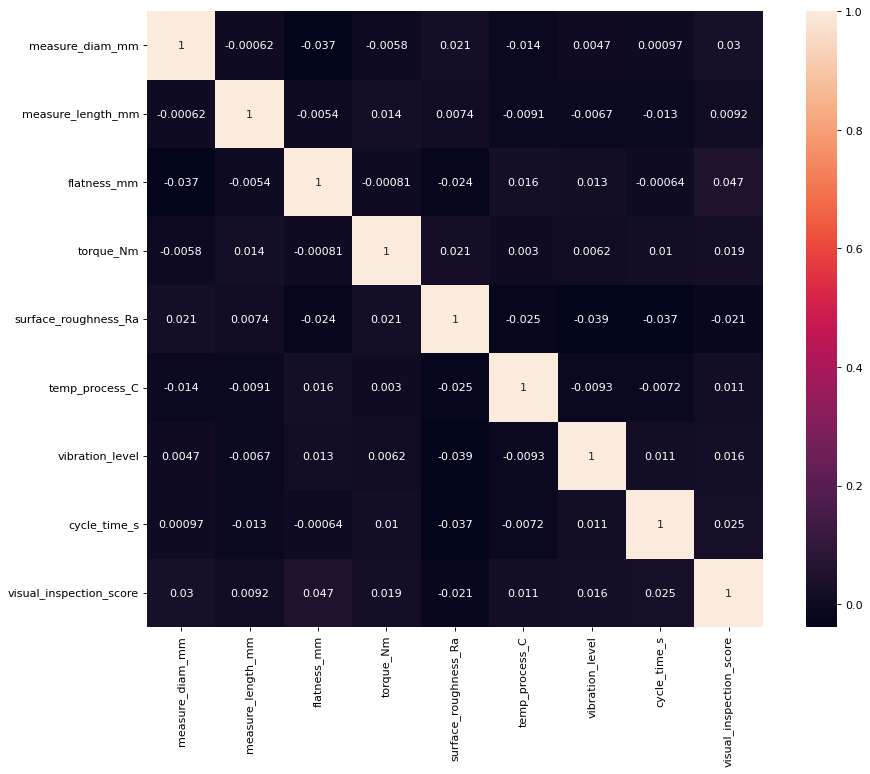

In [278]:
plt.figure(figsize=(14, 10), dpi=80)
sns.heatmap(
    df[par_processing_columns].corr(), 
    cbar=True, square=True, 
    yticklabels=df[par_processing_columns].columns, 
    xticklabels=df[par_processing_columns].columns, 
    annot=True, 
    annot_kws={'size':10})

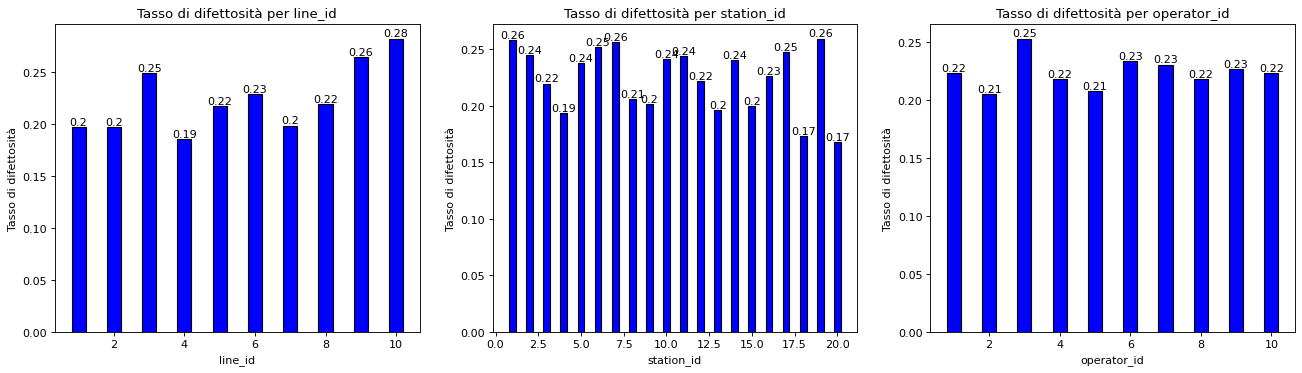

In [279]:
# Difettosità per linea, stazione e operatore
defect_rate_list = ["line_id", "station_id", "operator_id"]
plt.figure(figsize=(20, 5), dpi=80)
for rate in defect_rate_list:
    plt.subplot(1, 3, defect_rate_list.index(rate) + 1)
    defect_rate = df.groupby(rate)["defect_label"].mean().sort_values(ascending=False)
    plt.bar_label(plt.bar(defect_rate.index, defect_rate, color="blue", width=0.4, edgecolor="black"), round(defect_rate, 2))
    plt.title("Tasso di difettosità per " + rate)
    plt.xlabel(rate)
    plt.ylabel("Tasso di difettosità")
plt.show()
    


## 2 - Rules for handling missing values ​​and outliers

The dataset does not contain missing values, however it is good practice to define handling rules to ensure **replicability** in real-world scenarios.

**Numerical Variables**

For numerical variables, the chosen imputation strategy is the **median**, as it is more robust than the mean in the presence of outliers.

**Categorical Variables**

For categorical variables, missing values are handled by assigning the state *Unknown*.

**Outlier Handling**

Regarding the handling of potential outliers in process and measurement variables, removing them is considered unnecessary and potentially harmful.

In industrial contexts, extreme or out-of-range values may represent abnormal process conditions associated with defect generation.

For this reason, a **conservative approach** has been adopted, maintaining such observations in the dataset to preserve potentially informative signals.

The method used for outlier detection is the IQR method:
<br>

$x < Q1 - 1.5*IQR$
<br>
$x > Q3 + 1.5*IQR$

<br>

Therefore, if we denote with $x$ the observed value, it is considered an outlier if it satisfies one of the above conditions.

### Imputation for Numerical Variables

In [280]:
imp = df[par_processing_columns].median() # Imputazione mediana
imp

measure_diam_mm             30.277000
measure_length_mm           49.450500
flatness_mm                 29.795000
torque_Nm                  303.522000
surface_roughness_Ra        29.670000
temp_process_C             111.266000
vibration_level              0.495252
cycle_time_s               200.839500
visual_inspection_score      0.510032
dtype: float64

In [281]:
df[par_processing_columns] = df[par_processing_columns].fillna(imp)

### Imputation for Categorical Variables

In [282]:
cat_columns = ["line_id", "station_id", "operator_id", "material_batch"]
df[cat_columns] = df[cat_columns].fillna("Unknown")

### Outlier Handling

In [283]:
# Utilizziamo il metodo IQR (Interquartile Range) per identificare gli outlier
for col in par_processing_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

measure_diam_mm: 0 outliers
measure_length_mm: 0 outliers
flatness_mm: 0 outliers
torque_Nm: 0 outliers
surface_roughness_Ra: 0 outliers
temp_process_C: 0 outliers
vibration_level: 0 outliers
cycle_time_s: 0 outliers
visual_inspection_score: 0 outliers


## 3 - Setting up variables

In this phase, the input variables for the machine learning models were prepared.

**Feature Selection**

The variables *part_id* and *material_batch* were excluded from the model as they were considered not informative.

* **part_id** is a unique identifier and therefore does not contain useful information for prediction  
* **material_batch** has very high cardinality, which could lead to poor generalization and increase the risk of overfitting  

---

**Time-Based Features**

Several time-based features were extracted from the production timestamp:

* Production year  
* Production month  
* Week of the year  
* Day of the week  
* Hour of production  

These variables allow the model to capture potential temporal patterns in the production process, such as:
- shift-related effects  
- production scheduling  
- operational variations over time  

Although the time window of the dataset is not particularly wide, these features may still capture relevant patterns related to production dynamics.

---

Finally, the dataset was sorted by *production_timestamp*, and the separation between input features and the target variable (*defect_label*) was performed.



### Separation of Variables  

La variabile *part_id* non risulta utile in quanto risulta essere un identificativo puro. Infatti essendo un identificativo unico il modello potrebbe memorizzare la relazione con l'output invece di imparare il pattern generale. Di conseguenza il modello sarà caratterizzato da overfitting.
Discorso analogo vale per la variabile *material_batch*, in questo caso non si tratta di un identificativo unico ma comunque la sua cardinalità risulta essere troppo alta per avere utilità informativa (2997/3000 valori unici) 

In [284]:
df["part_id"].unique() 

array([   1,    2,    3, ..., 2998, 2999, 3000], shape=(3000,))

In [285]:
df["material_batch"].unique() 

<StringArray>
['MB-2024W24-L02-575', 'MB-2024W30-L09-100', 'MB-2025W50-L06-297',
 'MB-2024W50-L04-747', 'MB-2025W37-L08-470', 'MB-2025W30-L03-643',
 'MB-2025W06-L07-301', 'MB-2025W04-L08-544', 'MB-2025W40-L10-129',
 'MB-2025W15-L08-530',
 ...
 'MB-2024W45-L10-641', 'MB-2024W42-L09-675', 'MB-2025W33-L03-691',
 'MB-2025W18-L01-962', 'MB-2024W48-L01-725', 'MB-2024W42-L01-892',
 'MB-2024W25-L02-563', 'MB-2024W06-L05-742', 'MB-2024W44-L10-564',
 'MB-2024W37-L08-541']
Length: 2997, dtype: str

In [286]:
# Eliminiamo la variabile part_id e material_batch perché non utili ai nostri fini
df_model = df.drop(["part_id", "material_batch"], axis=1)
df_model

,production_timestamp,line_id,station_id,operator_id,measure_diam_mm,measure_length_mm,flatness_mm,torque_Nm,surface_roughness_Ra,temp_process_C,vibration_level,cycle_time_s,visual_inspection_score,defect_label
0,2024-06-13 17:42:45,2,1,5,15.582,34.100,34.813,318.147,33.620,72.543,0.093695,146.532,0.602019,1
1,2024-07-26 10:36:48,9,14,4,42.377,30.260,36.116,379.256,23.610,82.438,0.957213,167.319,0.092746,0
2,2025-12-08 17:35:40,6,20,5,25.141,52.082,36.588,347.408,44.468,116.188,0.704572,109.165,0.227898,0
3,2024-12-09 12:56:36,4,4,7,35.427,44.593,27.404,183.803,20.679,144.932,0.648035,221.826,0.171139,0
4,2025-09-08 15:54:15,8,13,5,22.618,40.710,24.220,477.164,45.055,95.174,0.655439,179.126,0.914548,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2024-10-17 11:21:52,1,3,9,40.901,64.952,23.288,278.510,20.902,89.200,0.540174,280.940,0.146745,0
2996,2024-06-21 14:36:02,2,12,9,20.857,68.896,35.565,189.884,15.258,116.640,0.689168,193.230,0.716806,0
2997,2024-02-08 12:04:02,5,6,5,16.233,65.880,35.388,428.052,31.425,70.593,0.698880,203.112,0.385236,0
2998,2024-10-29 11:54:11,10,18,10,17.975,65.886,25.099,362.868,29.506,94.587,0.805216,120.720,0.350953,0


### Temporal Feature

In [287]:
df_model["production_timestamp"] = pd.to_datetime(df_model["production_timestamp"])
df_model["production_hour"] = df_model["production_timestamp"].dt.hour
df_model["production_dayofweek"] = df_model["production_timestamp"].dt.dayofweek
df_model["production_week"] = df_model["production_timestamp"].dt.isocalendar().week
df_model["production_month"] = df_model["production_timestamp"].dt.month
df_model["production_year"] = df_model["production_timestamp"].dt.isocalendar().year
df_model

,production_timestamp,line_id,station_id,operator_id,measure_diam_mm,measure_length_mm,flatness_mm,torque_Nm,surface_roughness_Ra,temp_process_C,vibration_level,cycle_time_s,visual_inspection_score,defect_label,production_hour,production_dayofweek,production_week,production_month,production_year
0,2024-06-13 17:42:45,2,1,5,15.582,34.100,34.813,318.147,33.620,72.543,0.093695,146.532,0.602019,1,17,3,24,6,2024
1,2024-07-26 10:36:48,9,14,4,42.377,30.260,36.116,379.256,23.610,82.438,0.957213,167.319,0.092746,0,10,4,30,7,2024
2,2025-12-08 17:35:40,6,20,5,25.141,52.082,36.588,347.408,44.468,116.188,0.704572,109.165,0.227898,0,17,0,50,12,2025
3,2024-12-09 12:56:36,4,4,7,35.427,44.593,27.404,183.803,20.679,144.932,0.648035,221.826,0.171139,0,12,0,50,12,2024
4,2025-09-08 15:54:15,8,13,5,22.618,40.710,24.220,477.164,45.055,95.174,0.655439,179.126,0.914548,1,15,0,37,9,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,2024-10-17 11:21:52,1,3,9,40.901,64.952,23.288,278.510,20.902,89.200,0.540174,280.940,0.146745,0,11,3,42,10,2024
2996,2024-06-21 14:36:02,2,12,9,20.857,68.896,35.565,189.884,15.258,116.640,0.689168,193.230,0.716806,0,14,4,25,6,2024
2997,2024-02-08 12:04:02,5,6,5,16.233,65.880,35.388,428.052,31.425,70.593,0.698880,203.112,0.385236,0,12,3,6,2,2024
2998,2024-10-29 11:54:11,10,18,10,17.975,65.886,25.099,362.868,29.506,94.587,0.805216,120.720,0.350953,0,11,1,44,10,2024


### Split features/target

In [288]:
# Ordiniamo il dataset per production_timestamp
df_model.sort_values("production_timestamp", ascending=True, inplace=True)

In [289]:
X = df_model.drop("defect_label", axis=1)
y = df_model["defect_label"]

In [290]:
X.shape

(3000, 18)

In [291]:
y.shape

(3000,)

## 4 - Data splitting, encoding and assessment of generalisation ability

**Train/Test Split**

To realistically evaluate the model’s generalization capability, the split between training and test sets was performed using a **time-based approach** rather than a random split.

In an industrial context, models are trained on historical data and then used to evaluate newly produced parts. For this reason, a random split may lead to overly optimistic performance estimates, as temporally and operationally similar data points could appear in both training and test sets.

A time-based split better reflects real-world conditions:

* the model is trained on past production data  
* evaluation is performed on more recent, unseen data  

This approach provides a more reliable estimate of the model’s ability to perform on future production.

An 80/20 split was applied.

**Note:** *A random split using train_test_split was also tested, but it did not lead to better overall model performance.*

---

**Target Variable Distribution**

As previously observed, the target variable *defect_label* is imbalanced, with approximately 76% conforming parts and 24% defective parts.

This imbalance reflects a realistic production scenario, where most components meet quality standards.

For this reason:
- no resampling techniques were applied  
- model performance was evaluated using appropriate classification metrics  
- particular attention was given to the model’s ability to correctly identify defective parts  

After applying the time-based split, the distribution of the target variable was verified:

- training set: ~22.5% defective parts  
- test set: ~22% defective parts  

The distributions are therefore very similar.

This indicates that the time-based split did not introduce significant imbalance and that the test set is representative of the training data distribution.

---

**Categorical Encoding & Feature Scaling**

For the final feature preparation, a **ColumnTransformer** was used to apply different transformations based on variable type:

* One-Hot Encoding for categorical variables (`line_id`, `station_id`, `operator_id`)  
* Standardization for the main numerical process variables  
* Standardization for the time-based features derived from the timestamp  


### Split Train/test

In [292]:
X

,production_timestamp,line_id,station_id,operator_id,measure_diam_mm,measure_length_mm,flatness_mm,torque_Nm,surface_roughness_Ra,temp_process_C,vibration_level,cycle_time_s,visual_inspection_score,production_hour,production_dayofweek,production_week,production_month,production_year
1751,2023-12-25 10:35:20,7,19,3,43.203,40.625,32.250,459.038,29.475,145.729,0.693934,159.692,0.112553,10,0,52,12,2023
1070,2023-12-25 10:52:20,10,19,8,17.472,36.973,21.398,122.175,19.860,142.086,0.468511,205.400,0.497701,10,0,52,12,2023
1439,2023-12-25 10:57:39,1,16,8,12.023,30.452,24.917,431.550,10.504,94.919,0.892788,123.446,0.276291,10,0,52,12,2023
605,2023-12-25 14:11:27,9,19,4,18.131,64.024,27.248,289.571,15.344,78.813,0.911362,172.172,0.849329,14,0,52,12,2023
1147,2023-12-25 14:33:51,1,11,7,43.797,35.661,36.891,246.868,43.220,126.825,0.018062,246.863,0.063369,14,0,52,12,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1556,2025-12-19 09:13:15,1,14,5,36.596,68.260,31.130,116.374,40.367,111.935,0.029211,285.327,0.017194,9,4,51,12,2025
1360,2025-12-19 11:25:33,1,9,9,30.933,45.735,33.588,170.546,37.757,132.414,0.777421,151.942,0.346853,11,4,51,12,2025
484,2025-12-19 12:27:23,4,16,9,31.274,68.495,25.499,182.322,43.188,137.113,0.579553,116.930,0.533544,12,4,51,12,2025
2785,2025-12-19 12:55:17,1,20,6,38.267,30.980,28.730,477.480,49.775,141.170,0.247234,190.920,0.433988,12,4,51,12,2025


In [293]:
# Prova fatta anche con train_test_split ma i risultati dei modelli non sono risultatiti migliori
# X_train, X_test, y_train, y_test = train_test_split(
   # X, y, test_size=0.2, random_state=0, stratify=y
#)

In [294]:
# Adesso facciamo lo split temporale. 80% per il training set
X_train = X[:2400]
X_train

,production_timestamp,line_id,station_id,operator_id,measure_diam_mm,measure_length_mm,flatness_mm,torque_Nm,surface_roughness_Ra,temp_process_C,vibration_level,cycle_time_s,visual_inspection_score,production_hour,production_dayofweek,production_week,production_month,production_year
1751,2023-12-25 10:35:20,7,19,3,43.203,40.625,32.250,459.038,29.475,145.729,0.693934,159.692,0.112553,10,0,52,12,2023
1070,2023-12-25 10:52:20,10,19,8,17.472,36.973,21.398,122.175,19.860,142.086,0.468511,205.400,0.497701,10,0,52,12,2023
1439,2023-12-25 10:57:39,1,16,8,12.023,30.452,24.917,431.550,10.504,94.919,0.892788,123.446,0.276291,10,0,52,12,2023
605,2023-12-25 14:11:27,9,19,4,18.131,64.024,27.248,289.571,15.344,78.813,0.911362,172.172,0.849329,14,0,52,12,2023
1147,2023-12-25 14:33:51,1,11,7,43.797,35.661,36.891,246.868,43.220,126.825,0.018062,246.863,0.063369,14,0,52,12,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
908,2025-07-23 15:49:20,5,6,1,42.272,66.216,35.449,117.550,17.307,97.206,0.683033,269.108,0.228733,15,2,30,7,2025
2448,2025-07-24 08:17:18,10,9,4,27.373,32.931,31.003,104.811,32.161,75.423,0.975998,203.859,0.953571,8,3,30,7,2025
149,2025-07-24 09:04:48,3,3,9,48.973,32.148,28.742,435.470,23.624,131.520,0.954858,179.341,0.773555,9,3,30,7,2025
625,2025-07-24 13:45:31,8,19,2,49.161,46.807,30.922,166.440,25.102,97.847,0.952377,294.349,0.576836,13,3,30,7,2025


In [295]:
y_train = y[:2400]
y_train

1751    0
1070    0
1439    0
605     0
1147    0
       ..
908     0
2448    0
149     0
625     0
595     0
Name: defect_label, Length: 2400, dtype: int64

In [296]:
X_test = X[2400:]
y_test = y[2400:]

In [297]:
X_test

,production_timestamp,line_id,station_id,operator_id,measure_diam_mm,measure_length_mm,flatness_mm,torque_Nm,surface_roughness_Ra,temp_process_C,vibration_level,cycle_time_s,visual_inspection_score,production_hour,production_dayofweek,production_week,production_month,production_year
576,2025-07-24 17:40:06,9,18,2,10.292,46.999,30.686,238.024,49.769,122.894,0.920459,299.834,0.944941,17,3,30,7,2025
2142,2025-07-25 08:05:24,2,15,1,20.782,32.460,36.378,236.404,38.003,119.792,0.551799,235.992,0.804993,8,4,30,7,2025
256,2025-07-25 09:15:52,7,1,8,25.640,61.899,30.914,484.054,15.763,124.183,0.914169,259.003,0.729325,9,4,30,7,2025
1078,2025-07-25 09:37:19,4,7,10,39.187,31.481,31.438,272.579,23.493,112.892,0.660337,191.069,0.876873,9,4,30,7,2025
1663,2025-07-25 10:29:45,4,3,6,48.084,61.179,34.139,479.216,14.545,121.508,0.482554,111.530,0.329831,10,4,30,7,2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1556,2025-12-19 09:13:15,1,14,5,36.596,68.260,31.130,116.374,40.367,111.935,0.029211,285.327,0.017194,9,4,51,12,2025
1360,2025-12-19 11:25:33,1,9,9,30.933,45.735,33.588,170.546,37.757,132.414,0.777421,151.942,0.346853,11,4,51,12,2025
484,2025-12-19 12:27:23,4,16,9,31.274,68.495,25.499,182.322,43.188,137.113,0.579553,116.930,0.533544,12,4,51,12,2025
2785,2025-12-19 12:55:17,1,20,6,38.267,30.980,28.730,477.480,49.775,141.170,0.247234,190.920,0.433988,12,4,51,12,2025


In [298]:
y_test

576     0
2142    0
256     0
1078    0
1663    0
       ..
1556    1
1360    0
484     0
2785    0
437     0
Name: defect_label, Length: 600, dtype: int64

In [299]:
# Percentuale di difetto per il training set
y_train.mean()

np.float64(0.22541666666666665)

In [300]:
# Percentuale di difetto per il test set
y_test.mean()

np.float64(0.22)

In [301]:
X_train.drop("production_timestamp", axis=1, inplace=True)
X_test.drop("production_timestamp", axis=1, inplace=True)

In [302]:
X_train.head()

,line_id,station_id,operator_id,measure_diam_mm,measure_length_mm,flatness_mm,torque_Nm,surface_roughness_Ra,temp_process_C,vibration_level,cycle_time_s,visual_inspection_score,production_hour,production_dayofweek,production_week,production_month,production_year
1751,7,19,3,43.203,40.625,32.250,459.038,29.475,145.729,0.693934,159.692,0.112553,10,0,52,12,2023
1070,10,19,8,17.472,36.973,21.398,122.175,19.860,142.086,0.468511,205.400,0.497701,10,0,52,12,2023
1439,1,16,8,12.023,30.452,24.917,431.550,10.504,94.919,0.892788,123.446,0.276291,10,0,52,12,2023
605,9,19,4,18.131,64.024,27.248,289.571,15.344,78.813,0.911362,172.172,0.849329,14,0,52,12,2023
1147,1,11,7,43.797,35.661,36.891,246.868,43.220,126.825,0.018062,246.863,0.063369,14,0,52,12,2023


### Encoding Categorical Variables - Scaling Numerical Variables

Categorical Variables: *line_id, station_id, operator_id*
Numerical Variables *measure_diam_mm, measure_length_mm, flatness_mm, torque_Nm, surface_roughness_Ra, temp_process_C, vibration_level, cycle_time_s, visual_inspection_score*

In [303]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [304]:
categorical_cols = [
    "line_id",
    "station_id",
    "operator_id"
]

In [305]:
temporal_cols = [
    "production_year",
    "production_month",
    "production_week",
    "production_dayofweek",
    "production_hour"
]

In [306]:
transf = ColumnTransformer(
    [
        ('ohe', OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ('ssc', StandardScaler(), par_processing_columns),
        ('tsc', StandardScaler(), temporal_cols)

    ], 
    remainder="passthrough"
)    

In [307]:
X_train = transf.fit_transform(X_train)
X_test = transf.transform(X_test)

In [308]:
X_train.shape

(2400, 54)

In [309]:
X_test.shape

(600, 54)

In [310]:
type(X_train)

numpy.ndarray

## 5 - Training and comparison of supervised models – Performance evaluations

**Logistic Regression**

Logistic Regression shows a good overall accuracy (around 78%), but fails to correctly identify defective parts.

The model tends to classify almost all observations as conforming parts, resulting in a recall equal to 0 for the defective class.

This behavior is likely due to:

* the moderate class imbalance in the dataset  
* the difficulty of linearly separating the two classes  
* the presence of non-linear relationships between process variables  

This result highlights the limitations of linear models in this context.

---

**Decision Tree**

The Decision Tree does not show significant improvements compared to Logistic Regression.

Similarly, the model tends to classify the vast majority of parts as conforming, resulting in a near-zero recall for the defective class.

This behavior suggests that the available variables do not provide a sufficiently strong signal to effectively distinguish defective parts.

This is consistent with the exploratory analysis, which showed a strong overlap between the distributions of variables across the two classes.

---

**Random Forest**

The Random Forest model shows better performance compared to the previous models.

In particular, it is the only model able to correctly identify a portion of defective parts.

On the test set, the model detects approximately 10% of defects, while maintaining a high precision (around 0.87).  
This means that when the model predicts a defect, it is highly likely to be correct.

However, the number of false negatives remains high, indicating that many defects are still not detected.

This result suggests that the dataset provides only a limited predictive signal for defect classification.

---

**False Negatives and False Positives Analysis**

From an industrial perspective, it is critical to analyze two types of errors.

*False Negatives*

A false negative corresponds to a defective part classified as conforming.

This is the most critical error, as it may lead to:

* defective parts being shipped to customers  
* risk of complaints or product recalls  
* negative impact on supplier reputation  

In the Random Forest model, the number of false negatives remains high, indicating that many defects are not detected.

---

*False Positives*

A false positive corresponds to a conforming part classified as defective.

This leads to:

* unnecessary scrap  
* increased inspection or rework costs  

In the Random Forest model, the number of false positives is very low, indicating that when the model signals a defect, it is highly reliable.




### Logistic Regression

In [311]:
lr = LogisticRegression()

In [312]:
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [313]:
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

In [314]:
print(classification_report(y_train, y_pred_train))

              precision    recall  f1-score   support

           0       0.77      1.00      0.87      1859
           1       1.00      0.00      0.00       541

    accuracy                           0.78      2400
   macro avg       0.89      0.50      0.44      2400
weighted avg       0.83      0.78      0.68      2400



In [315]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88       468
           1       0.00      0.00      0.00       132

    accuracy                           0.78       600
   macro avg       0.39      0.50      0.44       600
weighted avg       0.61      0.78      0.68       600



c:\Users\loren\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\loren\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\loren\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [326]:
def plot_confusion_matrix(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred) # tn, fp, fn, tp

    df_cm = pd.DataFrame(cm, 
                        index = ["Conforme", "Non conforme"],
                        columns = ["Predetto Conforme","Predetto Non conforme"]
                        )
    sns.heatmap(df_cm, annot=True, fmt='g')

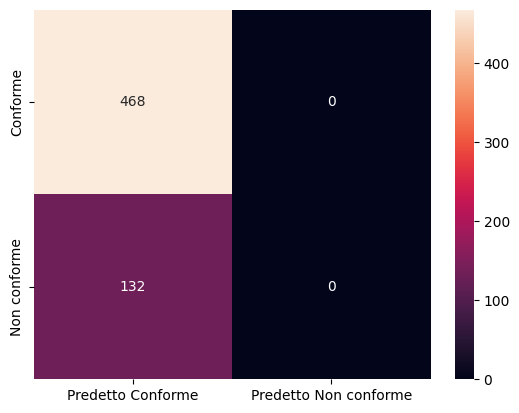

In [327]:
plot_confusion_matrix(y_test, y_pred_test)

### Decision Tree

In [316]:
dtc = DecisionTreeClassifier(
    criterion = "gini", # Oppure entropy
    max_depth=5, # Profondità massima
    min_samples_split=4, # Numero minimo di campioni per eseguire uno split
    min_samples_leaf=3, # Numero minimo di campioni per ogni foglia
    max_features=3, # Numero di feature considerate per ogni split
    random_state=0
)

In [317]:
dtc.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, 

In [318]:
y_pred_train_dtc = dtc.predict(X_train)
y_pred_test_dtc = dtc.predict(X_test)

In [319]:
print(classification_report(y_train, y_pred_train_dtc))

              precision    recall  f1-score   support

           0       0.78      1.00      0.87      1859
           1       0.81      0.02      0.05       541

    accuracy                           0.78      2400
   macro avg       0.80      0.51      0.46      2400
weighted avg       0.79      0.78      0.69      2400



In [320]:
print(classification_report(y_test, y_pred_test_dtc))

              precision    recall  f1-score   support

           0       0.78      1.00      0.88       468
           1       0.00      0.00      0.00       132

    accuracy                           0.78       600
   macro avg       0.39      0.50      0.44       600
weighted avg       0.61      0.78      0.68       600



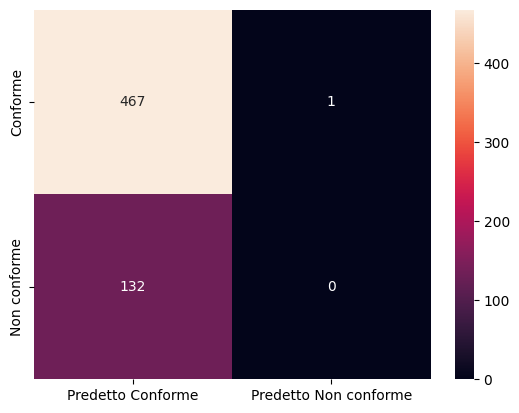

In [328]:
plot_confusion_matrix(y_test, y_pred_test_dtc)

### Random Forest

In [341]:
rfc = RandomForestClassifier(
    n_estimators=500,
    criterion="entropy",
    max_depth=5, # Profondità massima
    min_samples_split=5, # Numero minimo di campioni per eseguire uno split
    min_samples_leaf=3, # Numero minimo di campioni per ogni foglia
    max_features=0.8, # Numero di feature considerate per ogni split
    n_jobs=-1, # Numero di thread  
    random_state=0
)

In [342]:
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.8
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [343]:
y_pred_test_rfc = rfc.predict(X_test)
y_pred_train_rfc = rfc.predict(X_train)

In [338]:
print(classification_report(y_train, y_pred_train_rfc))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1859
           1       0.90      0.16      0.27       541

    accuracy                           0.81      2400
   macro avg       0.85      0.58      0.58      2400
weighted avg       0.83      0.81      0.75      2400



In [344]:
print(classification_report(y_test, y_pred_test_rfc))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89       468
           1       0.93      0.10      0.18       132

    accuracy                           0.80       600
   macro avg       0.86      0.55      0.53       600
weighted avg       0.83      0.80      0.73       600



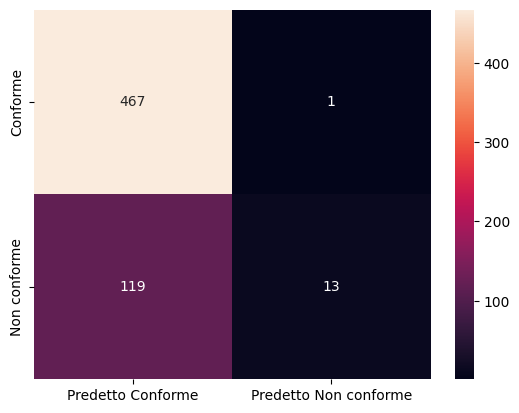

In [345]:
plot_confusion_matrix(y_test, y_pred_test_rfc)  

## 6 - Interpretability and practical utility

**Feature Importance Analysis**

To understand which variables most influence defect prediction, the feature importance of the Random Forest model was analyzed.

This method allows estimating the relative contribution of each variable to the predictive performance of the model.

The analysis shows that the most relevant variables are primarily related to **operational process conditions**.

In particular, the most important features are:

* machine vibration level  
* cycle time  
* process temperature  

These variables represent indicators of production stability and may be associated with abnormal machine or tooling conditions.

On the other hand, dimensional variables (diameter, length, flatness, surface roughness) show lower importance, suggesting that defects are more strongly linked to **process instability** rather than isolated dimensional deviations.

---

**Operational Value**

Although the Random Forest model does not detect all defects, it can still be used as a **decision support system**.

In particular, the model can be used to:

* identify parts with a high probability of being defective  
* route these parts to more in-depth quality inspections  
* monitor critical process parameters over time  

### Feature Importance

In [347]:
print(rfc.feature_importances_)

[0.00060907 0.00152136 0.00084941 0.00288383 0.00293742 0.00215706
 0.00114514 0.00114571 0.00525272 0.00336717 0.00302047 0.00119182
 0.00083145 0.00132017 0.00064228 0.00036562 0.00087988 0.00024041
 0.00066874 0.00186294 0.00041322 0.00097948 0.00160038 0.00064014
 0.0013528  0.00230872 0.00170436 0.00388802 0.00105242 0.00231151
 0.0009198  0.00056914 0.00167013 0.00143688 0.00209669 0.00270357
 0.00157317 0.00155795 0.00091648 0.00274634 0.06068118 0.05117347
 0.03884215 0.05768371 0.05358408 0.16620755 0.200242   0.18997043
 0.04543461 0.00172507 0.00979247 0.0251908  0.01525713 0.01888147]


In [348]:
transf.get_feature_names_out()

array(['ohe__line_id_1', 'ohe__line_id_2', 'ohe__line_id_3',
       'ohe__line_id_4', 'ohe__line_id_5', 'ohe__line_id_6',
       'ohe__line_id_7', 'ohe__line_id_8', 'ohe__line_id_9',
       'ohe__line_id_10', 'ohe__station_id_1', 'ohe__station_id_2',
       'ohe__station_id_3', 'ohe__station_id_4', 'ohe__station_id_5',
       'ohe__station_id_6', 'ohe__station_id_7', 'ohe__station_id_8',
       'ohe__station_id_9', 'ohe__station_id_10', 'ohe__station_id_11',
       'ohe__station_id_12', 'ohe__station_id_13', 'ohe__station_id_14',
       'ohe__station_id_15', 'ohe__station_id_16', 'ohe__station_id_17',
       'ohe__station_id_18', 'ohe__station_id_19', 'ohe__station_id_20',
       'ohe__operator_id_1', 'ohe__operator_id_2', 'ohe__operator_id_3',
       'ohe__operator_id_4', 'ohe__operator_id_5', 'ohe__operator_id_6',
       'ohe__operator_id_7', 'ohe__operator_id_8', 'ohe__operator_id_9',
       'ohe__operator_id_10', 'ssc__measure_diam_mm',
       'ssc__measure_length_mm', 'ssc__flatne

In [350]:
df_importance = pd.DataFrame(
    {
        "feature": transf.get_feature_names_out(),
        "importance": rfc.feature_importances_
    }
).sort_values("importance", ascending=False)
df_importance.head(10)


,feature,importance
46,ssc__vibration_level,0.200242
47,ssc__cycle_time_s,0.189970
45,ssc__temp_process_C,0.166208
40,ssc__measure_diam_mm,0.060681
43,ssc__torque_Nm,0.057684
44,ssc__surface_roughness_Ra,0.053584
41,ssc__measure_length_mm,0.051173
48,ssc__visual_inspection_score,0.045435
42,ssc__flatness_mm,0.038842
51,tsc__production_week,0.025191


<Axes: xlabel='importance', ylabel='feature'>

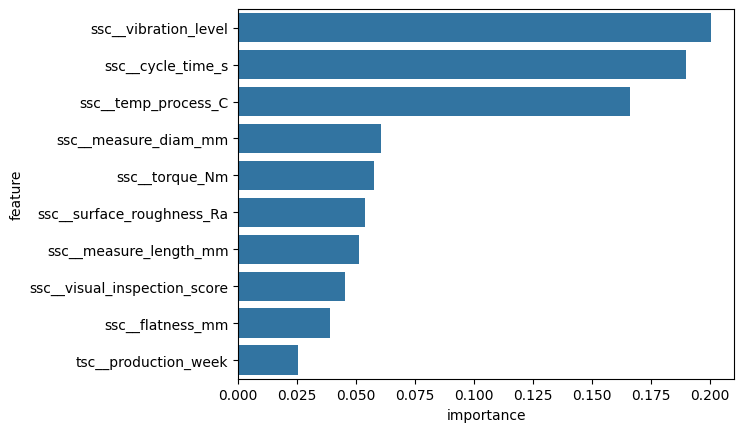

In [352]:
top_importance = df_importance.head(10)
sns.barplot(x=top_importance["importance"], y=top_importance["feature"])

## 7 - Results

**Summary of Results**

Among the tested models, Random Forest showed the best performance, being the only model able to identify a portion of defective parts.

However, the recall for the defective class remains limited, indicating that the current dataset does not contain sufficiently discriminative information to reliably detect all non-conformities.

This suggests that defect generation is likely driven by complex interactions and process conditions that are not fully captured by the available variables.

---

**Operational Recommendations**

For deployment in a production environment, the model should be used as a **decision support tool** rather than a fully automated classification system.

In particular, it can be used to:

* automatically route parts with a high probability of defect to additional quality checks  
* monitor critical process parameters in near real-time  
* support integration with MES or production monitoring systems  

Given the high precision of the model, predictions flagged as defective can be considered reliable and used to prioritize inspection efforts.

---

**Future Improvements**

To improve model performance, additional data should be collected, such as:

* more detailed process parameters  
* tool condition and wear information  
* machine maintenance data  
* enriched material batch information  

The integration of these variables could enable a more accurate identification of the conditions leading to defect generation.

---

**Final Considerations**

The main value of this project lies not only in predictive performance, but in its ability to:

* highlight the limitations of the current data  
* identify key process variables  
* provide actionable insights for process improvement  

This demonstrates how machine learning can be effectively used in industrial contexts to support decision-making, even when predictive accuracy is not perfect.